# Checking Distributional Assumptions of the Model by Comparing to Real Observed Data

The `riders.xlsx` and `drivers.xlsx` data sets are provided in the zip file that contains this notebook.

We begin by loading in the packages required for the following analyses.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from scipy.stats import kstwo
import seaborn as sns
from scipy.stats import chi2
import ast

We now load in the data in `riders.xlsx` and `drivers.xlsx` into pandas data frames.

In [103]:
# Load the data
riders_df = pd.read_excel('riders.xlsx')
drivers_df = pd.read_excel('drivers.xlsx')

## Driver Online Durations

We first investigate the distribution of the amount of times that the drivers spend online. The following plots a histogram of the amount of time each driver spends online.

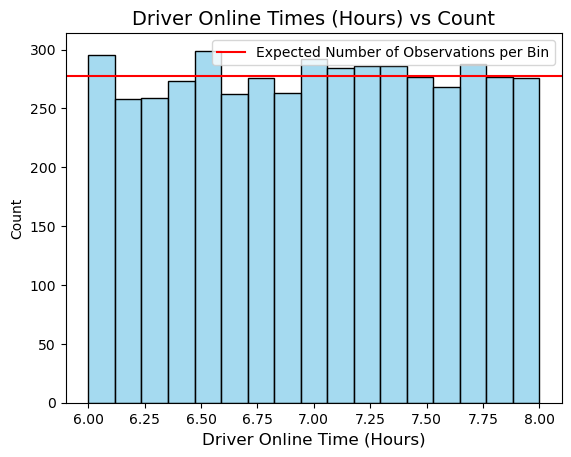

In [105]:
# Extract driver arrival/offline times
driver_arrivals = drivers_df['arrival_time']
driver_offline = drivers_df['offline_time']

# Find and plot total driver work times
driver_work_times = driver_offline - driver_arrivals

# Set number of bins
nbins=17

sns.histplot(driver_work_times, color="skyblue", bins=nbins)
plt.title("Driver Online Times (Hours) vs Count", fontsize=14)
plt.xlabel("Driver Online Time (Hours)", fontsize=12)

# Add horizontal line for expected number of counts in each bin
plt.axhline(y=len(driver_arrivals)/nbins, color="red", label="Expected Number of Observations per Bin")
plt.legend(loc="upper right")
plt.show()

Since we observe the data to be roughly uniformly distributed between 6 and 8, we complete a $\chi^2$ test that these data are Uniform(6,8) random variables.

In [78]:
def chi2_unif_test(data, lower, upper, bins):
    '''
    This function takes a vector, data, and computes the observed Chi-squared test statistic
    for the null hypothesis that these data are independtly distributed Uniform(lower, upper)
    random variables. 

    Inputs:
        data (vector) - A vector of observed data to calculate the test statistic on
        lower (real)  - A real number representing the lower bound for the uniform distribution
        upper (real)  - A real number representing the upper bound for the uniform distribution
        bins (int)    - The number of bins to split these data into

    Output:
        The observed Chi-squared test statistic that these data are independently distributed
        Uniform(lower, upper) random variables.
    '''

    # Number of observations in data
    n = len(data)

    # Define breakpoints used
    breakpoints = np.linspace(lower, upper, bins+1)

    # Expected number of observations in each bin
    expec_per_bin = np.repeat(n/bins, bins)

    # Calculate number of observations in each bin
    obs_per_bin = []

    for i in range(bins):
        obs_per_bin.append(sum((breakpoints[i] < data) & (data <= breakpoints[i+1])))

    # Convert back to numpy array for consistency
    obs_per_bin = np.array(obs_per_bin)

    # Return observed test statistic
    return(np.sum((obs_per_bin - expec_per_bin)**2/expec_per_bin))

# Define parameter values for chi-squared test
bins = 17
lower = 6
upper = 8

# Calculate the observed chi-squared statistic
chi2_obs = chi2_unif_test(data=driver_work_times, lower=lower, upper=upper, bins=bins)

# Print results:
print("The observed test statistic is", round(chi2_obs, 2),"and the critical value for these parameter values and data are:", round(chi2.ppf(1-0.05, df=bins-1), 2))

The observed test statistic is 8.98 and the critical value for these parameter values and data are: 26.3


We conclude by failing to reject the null hypothesis that these data are $\text{Uniform}(6,8)$ random variables since the observed test statistic is smaller than the critical value.

## Driver Inter-Arrival Times

### Kolmogorov-Smirnov (KS) Test

We now perform a KS test (as described in section 3.2) to test the null hypothesis that the driver inter-arrival times are distributed as $\text{Exp} (4.75)$ random variables.

In [87]:
def ks_test(data, func, lamb=1, plot=False):
    '''
    This function calculates the Kolmogorov-Smirnov test statistic for given data (assuming a true distribution that is exponential 
    with rate lambda). 

    Inputs:
        data (vector)   - The data vector of observed values
        func (function) - A python function that computes the exponential CDF for given data
        lamb (real)     - Rate parameter for exponential distribution
        plot (boolean)  - Should the data be plotted?

    Outputs:
        The observed test statistic for the KS test.
    '''

    # Convert the data to a numpy array
    data = np.array(data)

    n = len(data)

    # Convert data to standard uniform random variable
    U = np.sort(func(data, lamb))

    U_i = np.arange(1,n+1)

    # Theoretical standard uniform CDF at the jump points
    U_lower = np.max(np.abs(U_i/n - U))
    U_upper = np.max(np.abs(U - (U_i-1)/n))
    
    # KS test statistic
    D = max(U_lower, U_upper)
   
    # Return the test statistic and plotting vector if specified
    if plot==True:
        return D, U
    else:
        return D


def f_exp(x, lamb=1):
    ''' 
    Evaluate CDF at x for exponential random variable with rate parameter lamb

    Inputs:
        x (vector/real) - The data at which to compute the CDF.
        lamb (real)     - The rate parameter.  

    Outputs:
        Value of the exponential CDF at x (with rate parameter lamb).
    '''
    return 1-np.exp(-lamb*x)


# Find the driver inter-arrival times
driver_arrival_intervals = np.array(driver_arrivals[1:]) - np.array(driver_arrivals[0:-1])

# Calculate the KS test statistic for the driver inter-arrival times
ks_obs = ks_test(data=driver_arrival_intervals, func=f_exp, lamb=4.75)

# Compare to theoretical quantile values
critical_val = kstwo.isf(0.05, len(driver_arrival_intervals))
print("The observed test statistic is", round(ks_obs, 4),"and the critical value for these parameter values and data are:", round(critical_val, 4))

The observed test statistic is 0.011 and the critical value for these parameter values and data are: 0.0197


Hence, since $D_n < d_{n;1-\alpha}$ we fail to reject the null hypothesis that the driver inter-arrival times are distributed as Exp(4.75) random variables.

Let $X$ denote the driver inter-arrival times. We produce a plot of the transformed ECDFs, $U_1=F_1(X)$ and $U_2=F_2(X)$ (where $F_1(x)$ denotes the CDF for BoxCar's assumed distribution and $F_2(x)$ denotes the proposed distribution of driver inter-arrival times) with the CDF of a standard uniform random variable. We also produce a plot of the ECDF of the driver inter-arrival times against BoxCar's assumed exponential distribution and the proposed exponential distribution.

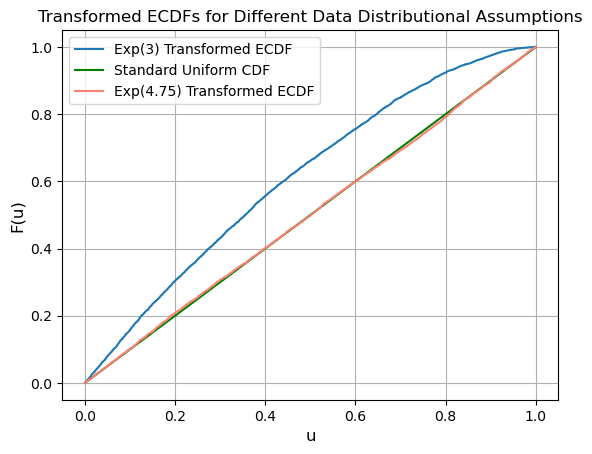

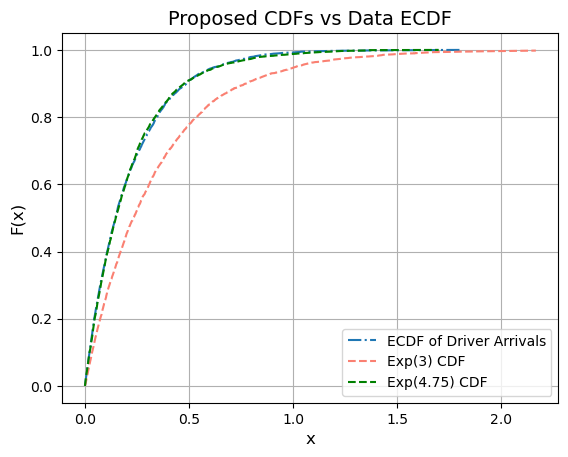

In [92]:
# Transformed data assuming these data are exp(3) and exp(4.75) random variables respectively
_, ECDF_trans_3 = ks_test(data=driver_arrival_intervals, func=f_exp, lamb=3, plot=True)
_, ECDF_trans_fitted = ks_test(data=driver_arrival_intervals, func=f_exp, lamb=4.75, plot=True)

# Plot the ECDF of the transformed CDFs for exp(3) and exp(4.75) r.v.s with the standard uniform CDF
plt.plot(ECDF_trans_3, np.linspace(0,1,len(ECDF_trans_3)), label="Exp(3) Transformed ECDF")
plt.plot(np.linspace(0,1,len(ECDF_trans_3)), np.linspace(0,1,len(ECDF_trans_3)), label="Standard Uniform CDF", color="green")
plt.plot(ECDF_trans_fitted, np.linspace(0,1,len(ECDF_trans_fitted)), label="Exp(4.75) Transformed ECDF", color="salmon")
plt.legend()
plt.title("Transformed ECDFs for Different Data Distributional Assumptions")
plt.ylabel("F(u)", fontsize=12)
plt.xlabel("u", fontsize=12)
plt.grid()
plt.show()

# Generate 5000 Exp(3) random variables and 5000 Exp(4.75) random variables
n = 5000
exp3 = []
exp_custom = []

for i in range(n):
    exp3.append(random.expovariate(3))
    exp_custom.append(random.expovariate(4.75))


# Calculate the ECDF for the driver inter-arrival times
ECDF = np.sort(driver_arrival_intervals)

# Plot the ECDF for the driver inter-arrival times and the proposed distributions for these data
plt.plot(ECDF, np.linspace(0,1,len(ECDF)), "-.", label="ECDF of Driver Arrivals")
plt.plot(np.sort(exp3)[:4990], np.linspace(0,1,n)[:4990], "--", label="Exp(3) CDF", color="salmon")
plt.plot(np.sort(exp_custom), np.linspace(0,1,n), "--", label="Exp(4.75) CDF", color="green")
plt.legend()
plt.ylabel("F(x)", fontsize=12)
plt.xlabel("x", fontsize=12)
plt.title("Proposed CDFs vs Data ECDF", fontsize=14)
plt.grid()
plt.show()

## Rider Inter-Arrival Times

We follow the same methodology as for the driver inter-arrival times above to test that they are distributed as $\text{Exponential}(35)$ random variables as opposed to BoxCar's assumed $\text{Exponential}(30)$ random variables. Note that we use the same KS test function as defined above.

In [93]:
# Extract rider request times
rider_requests = riders_df['request_time']

# Create rider inter-request times
rider_request_intervals = np.array(rider_requests[1:]) - np.array(rider_requests[0:-1])

# Calculate the observed KS statistic for the proposed distribution of these data
ks_obs = ks_test(data=rider_request_intervals, func=f_exp, lamb=35)

# Calculate the corresponding KS quantile value
critical_val = kstwo.isf(0.05, len(driver_arrival_intervals))
print("The observed test statistic is", round(ks_obs, 4),"and the critical value for these parameter values and data are:", round(critical_val, 4))

The observed test statistic is 0.0065 and the critical value for these parameter values and data are: 0.0197


Hence, since $D_n < d_{n,1-\alpha}$ we fail to reject the null hypothesis that the rider inter-request times are distributed as Exp(35) random variables.

Let $X$ denote the rider inter-arrival times. We produce a plot of the transformed ECDFs, $U_1=F_1(X)$ and $U_2=F_2(X)$ (where $F_1(x)$ denotes the CDF for BoxCar's assumed distribution and $F_2(x)$ denotes the proposed distribution of rider inter-arrival times) with the CDF of a standard uniform random variable. We also produce a plot of the ECDF of the rider inter-arrival times against BoxCar's assumed exponential distribution and the proposed exponential distribution.

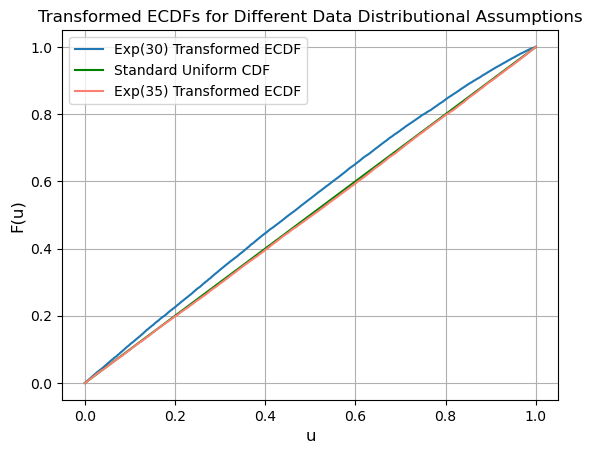

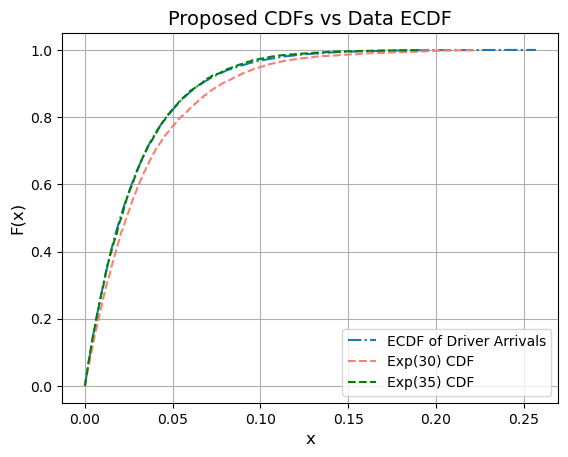

In [ ]:
# Transformed data assuming these data are exp(30) and exp(35) random variables respectively
_, ECDF_trans_30 = ks_test(data=rider_request_intervals, func=f_exp, lamb=30, plot=True)
_, ECDF_trans_35 = ks_test(data=rider_request_intervals, func=f_exp, lamb=35, plot=True)

# Plot the ECDF of the transformed CDFs for exp(30) and exp(35) r.v.s with the standard uniform CDF
plt.plot(ECDF_trans_30, np.linspace(0,1,len(ECDF_trans_30)), label="Exp(30) Transformed ECDF")
plt.plot(np.linspace(0,1,len(ECDF_trans_30)), np.linspace(0,1,len(ECDF_trans_30)), label="Standard Uniform CDF", color="green")
plt.plot(ECDF_trans_35, np.linspace(0,1,len(ECDF_trans_35)), label="Exp(35) Transformed ECDF", color="salmon")
plt.legend()
plt.grid()
plt.title("Transformed ECDFs for Different Data Distributional Assumptions")
plt.ylabel("F(u)", fontsize=12)
plt.xlabel("u", fontsize=12)
plt.show()

# Generate 5000 Exp(30) random variables and 5000 Exp(35) random variables
n = 5000
exp30 = []
exp35 = []

for i in range(n):
    exp30.append(random.expovariate(30))
    exp35.append(random.expovariate(35))

# Calculate the ECDF for the rider inter-request times
ECDF = np.sort(rider_request_intervals)

# Plot the ECDF for the rider inter-request times and the proposed distributions for these data
plt.plot(ECDF, np.linspace(0,1,len(ECDF)), "-.", label="ECDF of Driver Arrivals")
plt.plot(np.sort(exp30)[:4995], np.linspace(0,1,n)[:4995], "--", label="Exp(30) CDF", color="salmon")
plt.plot(np.sort(exp35)[:4997], np.linspace(0,1,n)[:4997], "--", label="Exp(35) CDF", color="green")
plt.legend()
plt.grid()
plt.ylabel("F(x)", fontsize=12)
plt.xlabel("x", fontsize=12)
plt.title("Proposed CDFs vs Data ECDF", fontsize=14)
plt.show()

## Rider Pickup Location

We produce a set of marginal histograms for the $x$ and $y$ rider pickup locations to investigate the assumption that they are both independently distributed as $\text{Uniform}(0,20)$ random variables.

We also produce a scatter plot of the data to visualise their joint distribution.

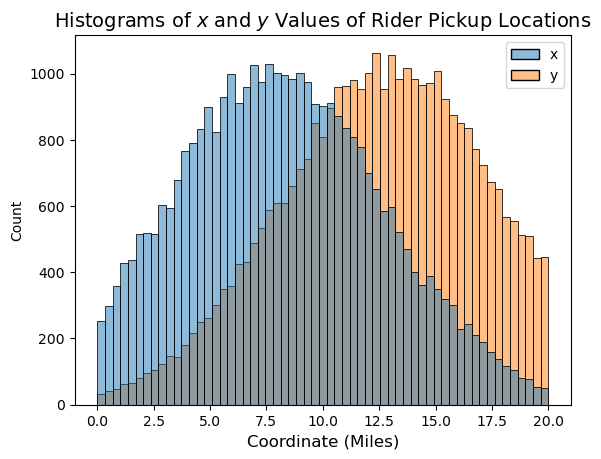

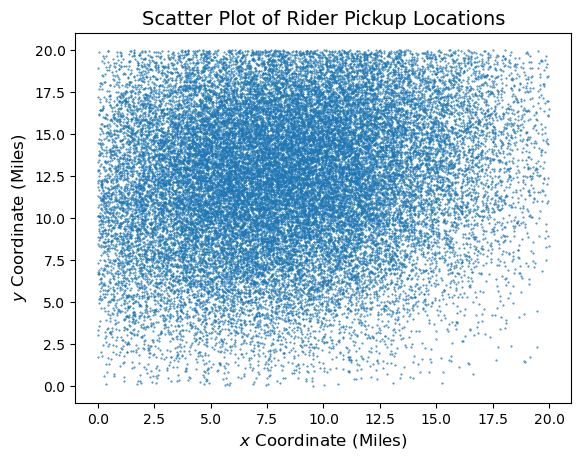

In [ ]:
# Create rider pickup location data frame (converting to numeric as it is a string)
rider_ploc = riders_df['pickup_location']
rider_ploc = np.array([ast.literal_eval(s) for s in rider_ploc])

# Plot the x and y coordinates of the pickup location as two overlayed histograms
rider_df = pd.DataFrame(rider_ploc, columns=[r"x", r"y"])
sns.histplot(rider_df)
plt.title(r"Histograms of $x$ and $y$ Values of Rider Pickup Locations", fontsize=14)
plt.xlabel("Coordinate (Miles)", fontsize=12)
plt.show()

# Plot the pickup locations in a scatterplot
plt.scatter(rider_ploc[:,0], rider_ploc[:,1], s=0.2)
plt.title("Scatter Plot of Rider Pickup Locations", fontsize=14)
plt.xlabel(r"$x$ Coordinate (Miles)", fontsize=12)
plt.ylabel(r"$y$ Coordinate (Miles)", fontsize=12)
plt.show()

The following code saves the rider pickup coordinate data to a csv file for use in the model fitting in $\texttt{R}$.

In [10]:
# Saves the rider pickup location data to a csv file
header = 'X Coordinate, Y Coordinate'
np.savetxt('rider_ploc.csv', rider_ploc, delimiter=',', header=header, comments='')

# Rider Drop-off Locations

The following code saves the rider dropoff coordinate data to a csv file for use in the model fitting in $\texttt{R}$.

In [11]:
# Creates a data frame for the coordinate data for dropoff locations and saves it to a csv file
rider_dloc = riders_df['dropoff_location']
rider_dloc = np.array([ast.literal_eval(s) for s in rider_dloc])

header = 'X Coordinate, Y Coordinate'
np.savetxt('rider_dloc.csv', rider_dloc, delimiter=',', header=header, comments='')


We produce a set of marginal histograms for the $x$ and $y$ rider drop-off locations to investigate the assumption that they are both independently distributed as $\text{Uniform}(0,20)$ random variables.

We also produce a scatter plot of the data to visualise their joint distribution.

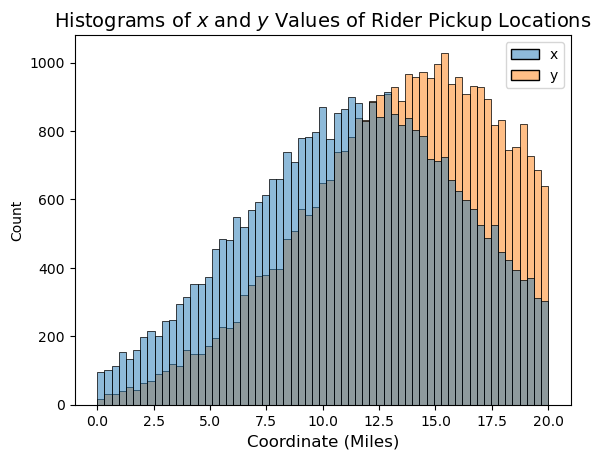

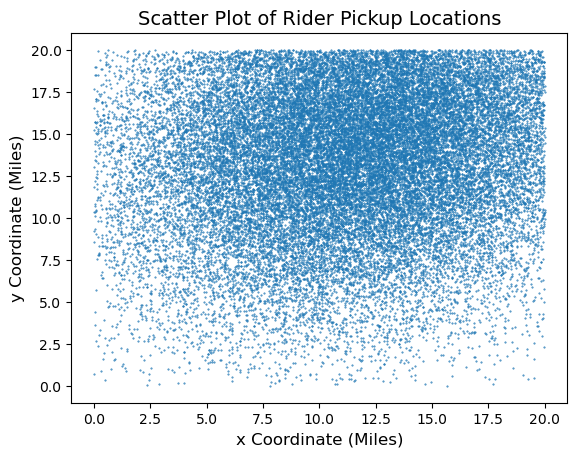

In [ ]:
# Produces histograms overlayed on the same plot for the x and y coordinate data
rider_df = pd.DataFrame(rider_dloc, columns=["x", "y"])
sns.histplot(rider_df)
plt.title(r"Histograms of $x$ and $y$ Values of Rider Pickup Locations", fontsize=14)
plt.xlabel("Coordinate (Miles)", fontsize=12)
plt.show()

# Creates a scatterplot of the coordinate data
plt.scatter(rider_dloc[:,0], rider_dloc[:,1], s=0.2)
plt.title("Scatter Plot of Rider Pickup Locations", fontsize=14)
plt.xlabel("x Coordinate (Miles)", fontsize=12)
plt.ylabel("y Coordinate (Miles)", fontsize=12)
plt.show()

## Driver Initial Location

We produce a set of marginal histograms for the $x$ and $y$ driver initial locations to investigate the assumption that they are both independently distributed as $\text{Uniform}(0,20)$ random variables.

We also produce a scatter plot of the data to visualise their joint distribution.

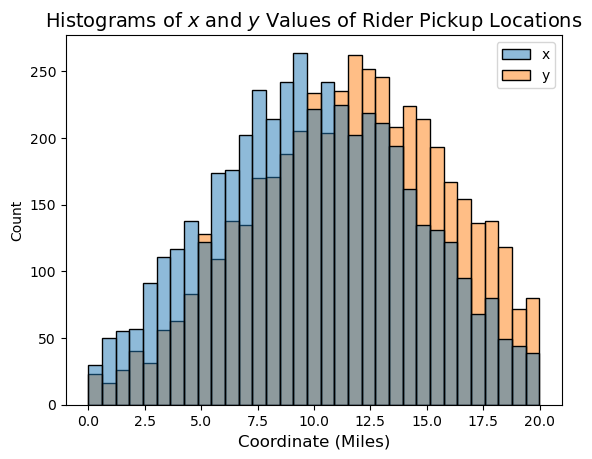

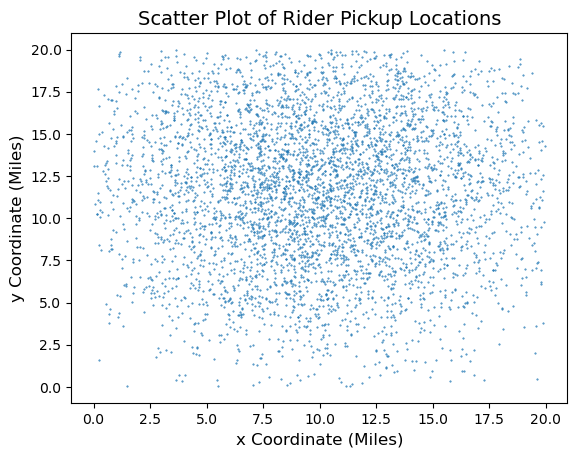

In [ ]:
# Extract and convert driver online locations to vector values
driver_oloc = drivers_df['initial_location']
driver_oloc = np.array([ast.literal_eval(s) for s in driver_oloc])

# Produces histograms overlayed on the same plot for the x and y coordinate data
driver_df = pd.DataFrame(driver_oloc, columns=["x", "y"])
sns.histplot(driver_df)
plt.title(r"Histograms of $x$ and $y$ Values of Rider Pickup Locations", fontsize=14)
plt.xlabel("Coordinate (Miles)", fontsize=12)
plt.show()

# Creates a scatterplot of the coordinate data
plt.scatter(driver_oloc[:,0], driver_oloc[:,1], s=0.2)
plt.title("Scatter Plot of Rider Pickup Locations", fontsize=14)
plt.xlabel("x Coordinate (Miles)", fontsize=12)
plt.ylabel("y Coordinate (Miles)", fontsize=12)
plt.show()

The following code saves the driver initial coordinate data to a csv file for use in the model fitting in $\texttt{R}$.

In [14]:
# Save the driver online times to a csv file
header = 'X Coordinate, Y Coordinate'
np.savetxt('driver_oloc.csv', driver_oloc, delimiter=',', header=header, comments='')

## Trip Distance Distribution

Finally, we investigate the distribtuion of the trip times. We begin by extracting the trip times from the data and filtering out the abandoned or unfinished trips.

In [15]:
# Re-read the data
riders_df = pd.read_excel('riders.xlsx')
dropoff_locs = riders_df["dropoff_location"]
pickup_locs = np.array(riders_df["pickup_location"])

# Find the trip times
trip_times = np.array(riders_df["dropoff_time"]) - np.array(riders_df["pickup_time"])

# Find indices of trips that were not completed (at the end of the simulation)
miss_vals = np.where(trip_times<0)[0]
# Find trips that were abandoned
abandoned_trips = np.where(trip_times==0)

# Refine the trip times to only those that were completed
trip_times = np.delete(trip_times, miss_vals)
trip_times = np.delete(trip_times, abandoned_trips)

We now produce plots of BoxCar's assumed distribution of trips times and the proposed distribution of trip times.

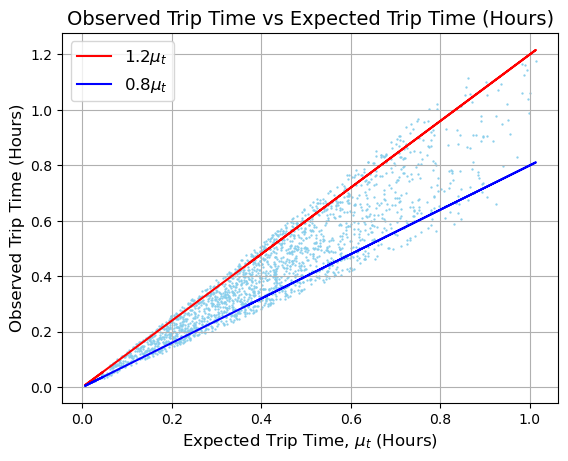

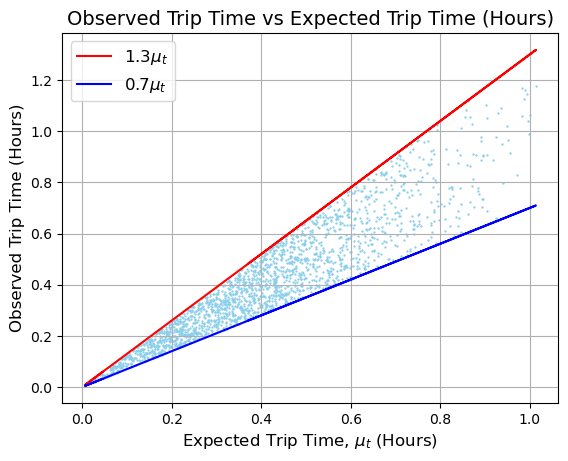

In [ ]:
def dist(x,y):
    '''
    Takes two 2d vectors, x and y, of the same length and calculates and returns the Euclidean distance between the pairs in x and y.

    Inputs:
        x (NumPy vector) - A vector of 2d vectors.
        y (NumPy vector) - A vector of 2d vectors.

    Outputs:
        A vector (same length as x and y) of Euclidean distances between the pairs in x and y.
    '''

    # Initialise the list of Euclidean distances
    dists = []

    # Calculates the Euclidean distance between pairs in x and y and appends them in order to dists
    for i in range(len(x)): 
        dists.append(np.sqrt((y[i][0] - x[i][0])**2 + (y[i][1] - x[i][1])**2))
    return dists

# Find the distances between the rider pickup and dropoff locations
dists = dist(rider_ploc, rider_dloc)

# Find the expected time for the trip to take
mu_t = np.array(dists)/20
mu_t = np.delete(mu_t, miss_vals)
mu_t = np.delete(mu_t, abandoned_trips)

# Consider only the first 1000 trips for clarity
mu_t2 = mu_t[0:2000]
trip_times2 = trip_times[0:2000]

# Plot the first 1000 trip times and overlay lines for 1.2 and 0.8 times the expected trip length
plt.scatter(mu_t2, y=trip_times2, s=0.4, color="skyblue")
plt.plot(mu_t2, 1.2*mu_t2, color="red", label=r"1.2$\mu_t$")
plt.plot(mu_t2, 0.8*mu_t2, color="blue", label=r"0.8$\mu_t$")
plt.xlabel(r"Expected Trip Time, $\mu_t$ (Hours)", fontsize=12)
plt.ylabel("Observed Trip Time (Hours)", fontsize=12)
plt.title("Observed Trip Time vs Expected Trip Time (Hours)", fontsize=14)
plt.legend(fontsize=12)
plt.grid()
plt.show()

# Plot the first 1000 trip times and overlay lines for 1.3 and 0.7 times the expected trip length
plt.scatter(mu_t2, y=trip_times2, s=0.4, color="skyblue")
plt.plot(mu_t2, 1.3*mu_t2, color="red", label=r"1.3$\mu_t$")
plt.plot(mu_t2, 0.7*mu_t2, color="blue", label=r"0.7$\mu_t$")
plt.xlabel(r"Expected Trip Time, $\mu_t$ (Hours)", fontsize=12)
plt.ylabel("Observed Trip Time (Hours)", fontsize=12)
plt.title("Observed Trip Time vs Expected Trip Time (Hours)", fontsize=14)
plt.legend(fontsize=12)
plt.grid()
plt.show()


We begin by scaling the observed trip times by dividing by the expected trip times, $\mu_t$. We plot the results in a histogram.

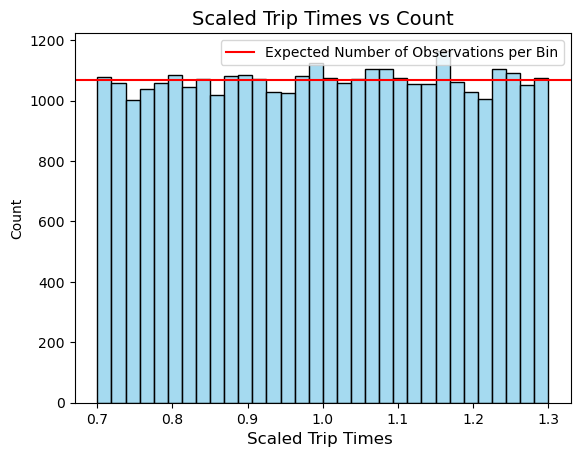

In [113]:
# Calculate the scaled trip times
scaled_trip_times = trip_times/mu_t
nbins = 32

# Plot a histogram of the scaled trip times
sns.histplot(scaled_trip_times, color="skyblue", bins=nbins)
plt.title("Scaled Trip Times vs Count", fontsize=14)
plt.xlabel("Scaled Trip Times ", fontsize=12)

# Add horizontal line for expected number of counts in each bin
plt.axhline(y=len(scaled_trip_times)/nbins, color="red", label="Expected Number of Observations per Bin")
plt.legend(loc="upper right")
plt.show()

This plot inidicate that the trip times are better modelled by a $\text{Uniform}(0.7,1.3)$ distribution. We test the null hypothesis that these data are $\text{Uniform}(0.7,1.3)$ random variables with a chi-squared test. We follow the same methodology and use the same functions as were used for the driver online times in the code below:

In [116]:
# Define parameter values for chi-squared test
bins = 100
lower = 0.7
upper = 1.3

# Calculate the observed chi-squared statistic
chi2_obs = chi2_unif_test(data=scaled_trip_times, lower=lower, upper=upper, bins=bins)

# Print results:
print("The observed test statistic is", round(chi2_obs, 2),"and the critical value for these parameter values and data are:", round(chi2.ppf(1-0.05, df=bins-1), 2))

The observed test statistic is 104.67 and the critical value for these parameter values and data are: 123.23


We conclude this test by failing to reject the null hypothesis that these data are distributed as $\text{Uniform}(0.7,1.3)$ random variables since the observed test statistic is less than the critical value for this test.